In [20]:
pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 MB 5.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 4.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [torchvision] [torchvision]
Note: you may need to restart the kernel to use updated packages.


Total images: 75
Train set: 53 samples
Validation set: 14 samples
Test set: 8 samples
Class weights: {np.uint8(0): 0.34096151239160677, np.uint8(1): 20.0, np.uint8(2): 20.0}
Epoch 1/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - dice_coef: 0.2393 - loss: 0.6253 - val_dice_coef: 0.2090 - val_loss: 0.6036 - learning_rate: 5.0000e-05
Epoch 2/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - dice_coef: 0.2663 - loss: 0.4722 - val_dice_coef: 0.2456 - val_loss: 0.5293 - learning_rate: 5.0000e-05
Epoch 3/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - dice_coef: 0.2781 - loss: 0.4537 - val_dice_coef: 0.2610 - val_loss: 0.5052 - learning_rate: 5.0000e-05
Epoch 4/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - dice_coef: 0.2826 - loss: 0.4389 - val_dice_coef: 0.2624 - val_loss: 0.4997 - learning_rate: 5.0000e-05
Epoch 5/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - dice_coef: 0.2845 - loss: 0.4297 - val_dice_coef: 0.2585 - val_loss: 0.4989 - learning_rate: 5.0000e-05
Epoch 6/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - 

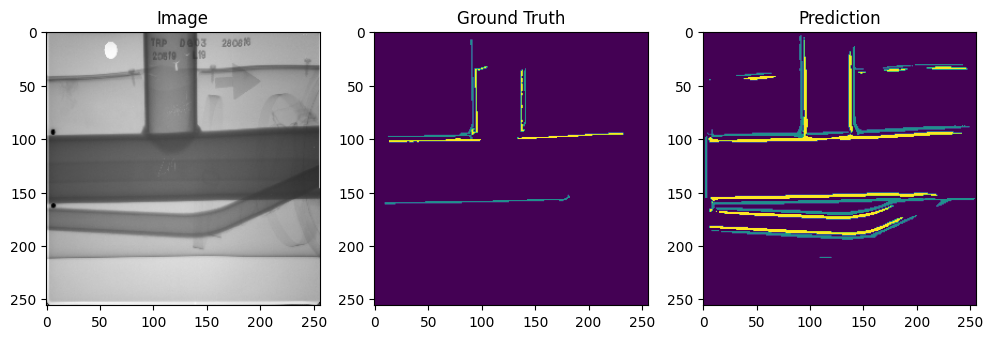

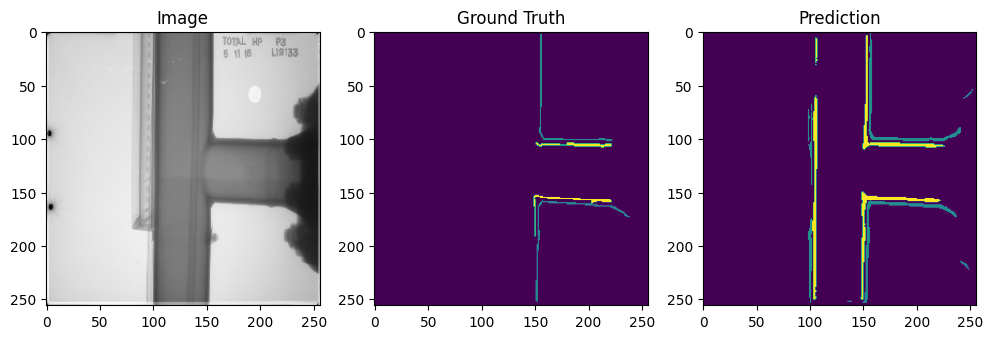

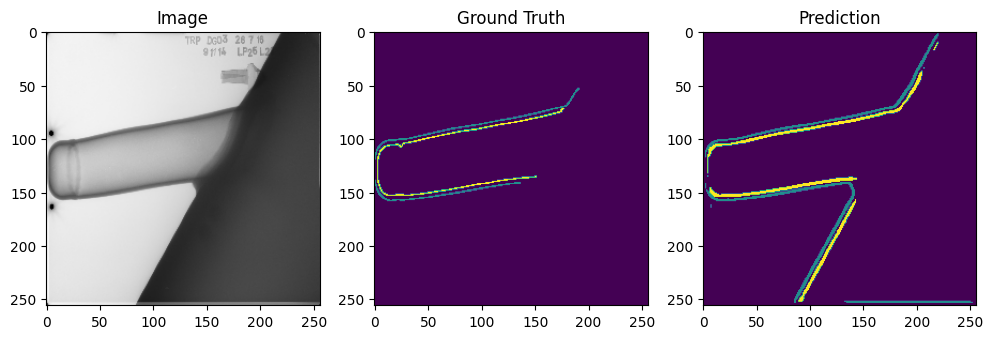

In [33]:
import os
import cv2
import numpy as np
import tensorflow as tf
import torch
from torch.nn import AdaptiveMaxPool2d
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, UpSampling2D,
                                     concatenate, BatchNormalization, Activation, Dropout)
from tensorflow.keras.models import Model

# Configuration
IMG_HEIGHT, IMG_WIDTH = 256, 256
NUM_CLASSES = 3
BATCH_SIZE = 8
BUFFER_SIZE = 100
EPOCHS = 120

IMAGE_DIR = '/Users/salah/Desktop/intern/pipe_segmentation/images'
MASK_DIR = '/Users/salah/Desktop/intern/pipe_segmentation/generated_segmentation_masks'

def preprocess_mask(mask):
    mask = np.where(mask == 127, 1, mask)
    mask = np.where(mask == 255, 2, mask)
    mask = np.where(mask < 1, 0, mask)
    return mask.astype(np.uint8)

def adaptive_maxpool_mask_resize(mask_np, output_size=(IMG_HEIGHT, IMG_WIDTH)):
    mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).float()
    adaptive_pool = AdaptiveMaxPool2d(output_size)
    pooled_mask = adaptive_pool(mask_tensor)
    pooled_mask_np = pooled_mask.squeeze().byte().numpy()
    return pooled_mask_np

# Load images and masks
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')])
mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.endswith('.png')])

image_dict = {os.path.splitext(f)[0]: f for f in image_files}
mask_dict = {os.path.splitext(f)[0].replace('_processed_annotated_mask', ''): f for f in mask_files}

X, Y = [], []

for base_name, img_file in image_dict.items():
    if base_name in mask_dict:
        img = cv2.imread(os.path.join(IMAGE_DIR, img_file))
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        mask = cv2.imread(os.path.join(MASK_DIR, mask_dict[base_name]), cv2.IMREAD_GRAYSCALE)
        mask = preprocess_mask(mask)
        mask = adaptive_maxpool_mask_resize(mask, (IMG_HEIGHT, IMG_WIDTH))
        X.append(img)
        Y.append(mask)

X = np.array(X, dtype=np.uint8)
Y = np.array(Y, dtype=np.uint8)

print(f"Total images: {len(X)}")

# One-hot encode masks
Y = tf.keras.utils.to_categorical(Y, num_classes=NUM_CLASSES)

# Train/val/test split
X_temp, X_test, Y_temp, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.2, random_state=42)

print(f"Train set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

# Class weights calculation
Y_train_labels = np.argmax(Y_train, axis=-1).astype(np.uint8)
all_pixels = Y_train_labels.flatten()
pixel_counts = Counter(all_pixels)
total_pixels = len(all_pixels)

class_weights = {cls: total_pixels / (NUM_CLASSES * count) for cls, count in pixel_counts.items()}
clipped_weights = {k: min(v, 20.0) for k, v in class_weights.items()}
print("Class weights:", clipped_weights)

weights_tensor = tf.constant([clipped_weights[i] for i in range(NUM_CLASSES)], dtype=tf.float32)

# Weighted focal loss using class weights
def weighted_focal_loss(alpha=weights_tensor, gamma=2.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=-1))
    return loss

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    denominator = tf.reduce_sum(y_true_f + y_pred_f, axis=0)
    return 1 - tf.reduce_mean((2. * intersection + smooth) / (denominator + smooth))

def combined_loss(y_true, y_pred):
    return 0.5 * weighted_focal_loss()(y_true, y_pred) + 0.5 * dice_loss(y_true, y_pred)

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
    denominator = tf.reduce_sum(y_true_f + y_pred_f, axis=0)
    return tf.reduce_mean((2. * intersection + smooth) / (denominator + smooth))

# Your U-Net model definition remains the same (not repeated here for brevity)
def conv_block(x, filters, dropout_rate=0.1):
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)
    return x

def improved_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    inputs = Input(input_shape)
    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D()(c1)
    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D()(c2)
    c3 = conv_block(p2, 256)
    p3 = MaxPooling2D()(c3)
    c4 = conv_block(p3, 512, dropout_rate=0.3)
    u5 = UpSampling2D()(c4)
    u5 = concatenate([u5, c3])
    c5 = conv_block(u5, 256)
    u6 = UpSampling2D()(c5)
    u6 = concatenate([u6, c2])
    c6 = conv_block(u6, 128)
    u7 = UpSampling2D()(c6)
    u7 = concatenate([u7, c1])
    c7 = conv_block(u7, 64)
    outputs = Conv2D(num_classes, 1, activation='softmax')(c7)
    return Model(inputs, outputs)

model = improved_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=combined_loss,
    metrics=[dice_coef]
)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1)
]

# Prepare tf.data pipelines (augment function remains the same, not repeated here)
def augment(image, mask):
    image = tf.cast(image, tf.float32)
    mask = tf.cast(mask, tf.float32)  # one-hot mask

    seed = tf.random.uniform([], maxval=10000, dtype=tf.int32)
    image = tf.image.stateless_random_flip_left_right(image, seed=[seed, 0])
    mask = tf.image.stateless_random_flip_left_right(mask, seed=[seed, 0])
    image = tf.image.stateless_random_flip_up_down(image, seed=[seed, 1])
    mask = tf.image.stateless_random_flip_up_down(mask, seed=[seed, 1])
    image = tf.image.stateless_random_brightness(image, max_delta=0.2, seed=[seed, 2])
    image = tf.image.stateless_random_contrast(image, 0.8, 1.2, seed=[seed, 3])
    image = tf.image.stateless_random_saturation(image, 0.8, 1.2, seed=[seed, 4])
    image = tf.image.stateless_random_hue(image, 0.05, seed=[seed, 5])
    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)
    return image, mask

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Simple visualization helper to check predictions on val set
def visualize_prediction(model, dataset, num=3):
    for images, masks in dataset.take(1):
        preds = model.predict(images)
        preds_labels = tf.argmax(preds, axis=-1)
        true_labels = tf.argmax(masks, axis=-1)
        for i in range(num):
            plt.figure(figsize=(12,4))
            plt.subplot(1,3,1)
            plt.title("Image")
            plt.imshow(images[i].numpy().astype(np.uint8))
            plt.subplot(1,3,2)
            plt.title("Ground Truth")
            plt.imshow(true_labels[i].numpy())
            plt.subplot(1,3,3)
            plt.title("Prediction")
            plt.imshow(preds_labels[i].numpy())
            plt.show()

# Call visualization after training
visualize_prediction(model, val_ds, num=3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
Class 0 IoU: 0.9716
Class 1 IoU: 0.4406
Class 2 IoU: 0.4303


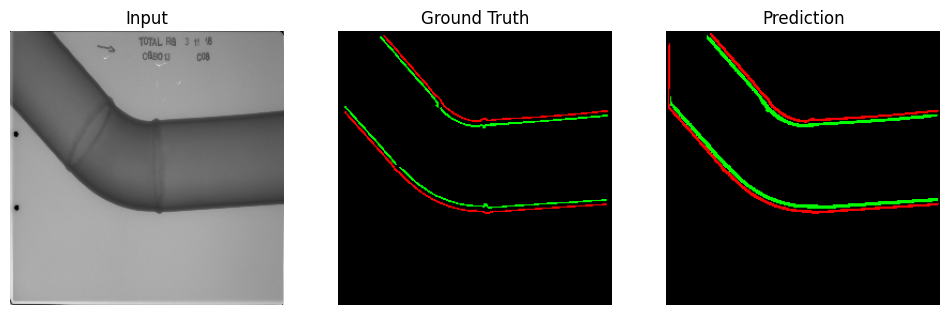

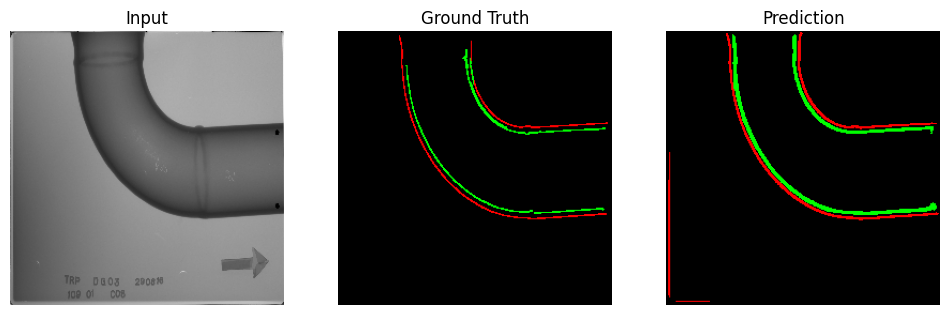

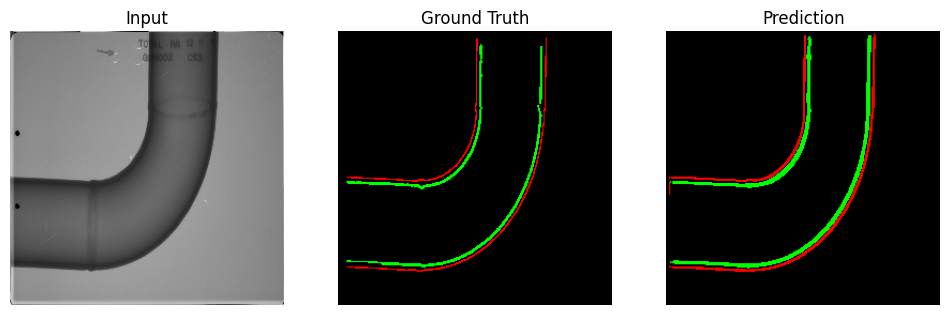

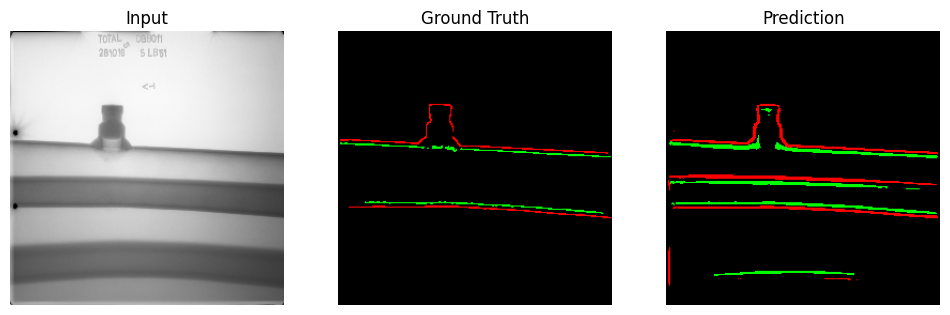

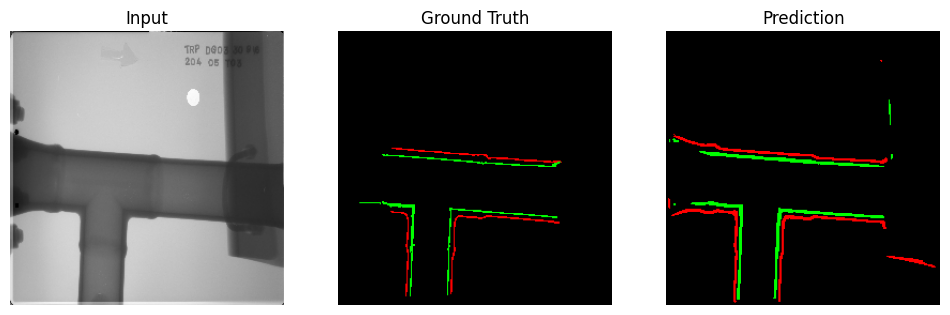

In [38]:
# Prediction & Postprocessingb
def postprocess_mask(pred_mask):
    mask = np.argmax(pred_mask, axis=-1).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_clean = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask_clean

preds = model.predict(test_ds)
pred_labels = np.argmax(preds, axis=-1)
Y_test_labels = np.argmax(Y_test, axis=-1)

# Evaluation
from sklearn.metrics import jaccard_score

def calculate_iou(y_true, y_pred, class_id):
    y_true_flat = (y_true.flatten() == class_id).astype(np.uint8)
    y_pred_flat = (y_pred.flatten() == class_id).astype(np.uint8)
    return jaccard_score(y_true_flat, y_pred_flat)

for cls in range(NUM_CLASSES):
    iou = calculate_iou(Y_test_labels, pred_labels, cls)
    print(f"Class {cls} IoU: {iou:.4f}")

# Visualization
colors = [[0, 0, 0], [255, 0, 0], [0, 255, 0]]

def colorize_mask(mask):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, color in enumerate(colors):
        color_mask[mask == class_id] = color
    return color_mask

for i in range(5):
    img = X_test[i]
    true_mask = np.argmax(Y_test[i], axis=-1)
    pred_mask = pred_labels[i]

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Input")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(colorize_mask(true_mask))
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(colorize_mask(pred_mask))
    plt.title("Prediction")
    plt.axis('off')

    plt.show()

In [41]:
model.save('/Users/salah/Desktop/intern/pipe_segmentation/saved_models/pipe_unet_model.keras')

In [15]:
pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 5.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-image] [scikit-image]
Note: you may need to restart the kernel to use updated packages.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
📊 Thickness stats for Test_0:
  ✅ Min     = 0.21 mm at (np.int64(114), np.int64(41))
  ✅ Max     = 2.05 mm at (np.int64(20), np.int64(57))
  ✅ Mean    = 0.49 mm
  ✅ Median  = 0.30 mm
  ✅ Std Dev = 0.47 mm


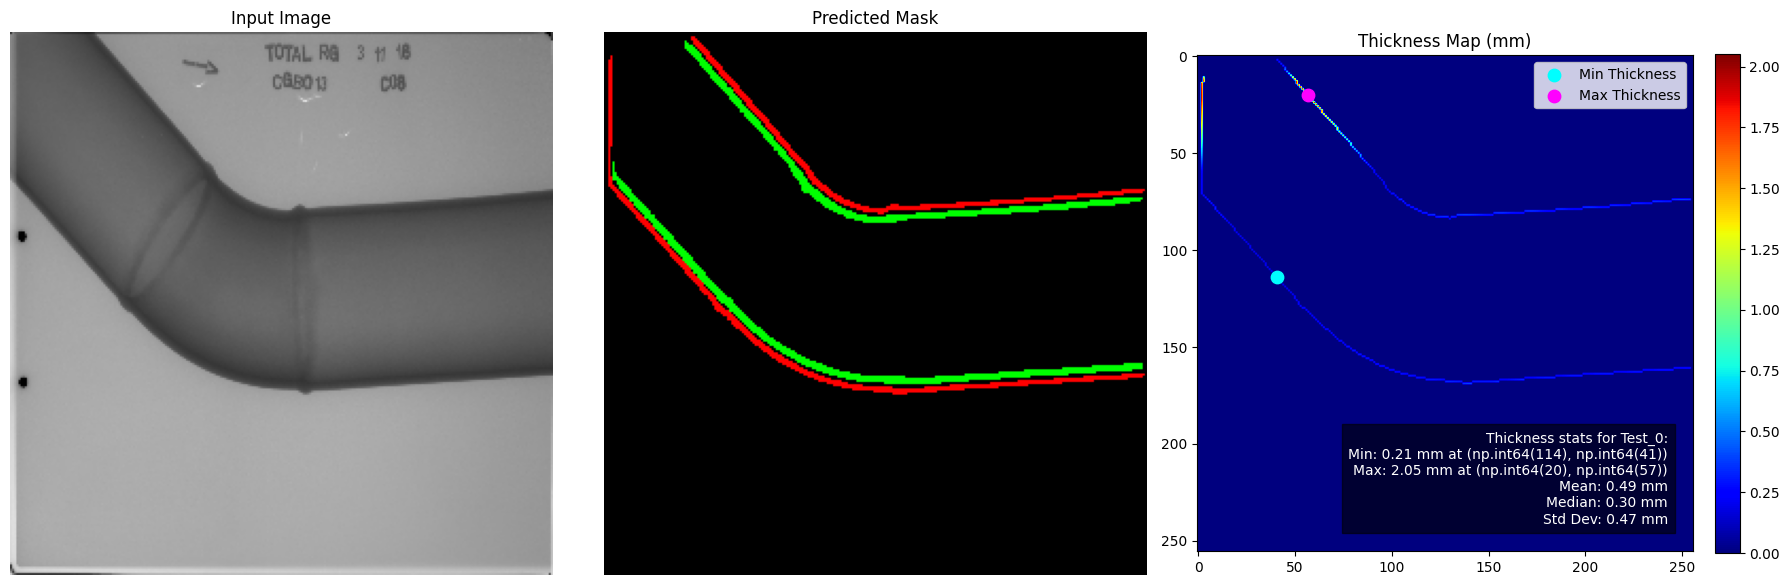

📊 Thickness stats for Test_1:
  ✅ Min     = 0.22 mm at (np.int64(102), np.int64(77))
  ✅ Max     = 14.81 mm at (np.int64(248), np.int64(3))
  ✅ Mean    = 2.65 mm
  ✅ Median  = 0.39 mm
  ✅ Std Dev = 3.95 mm


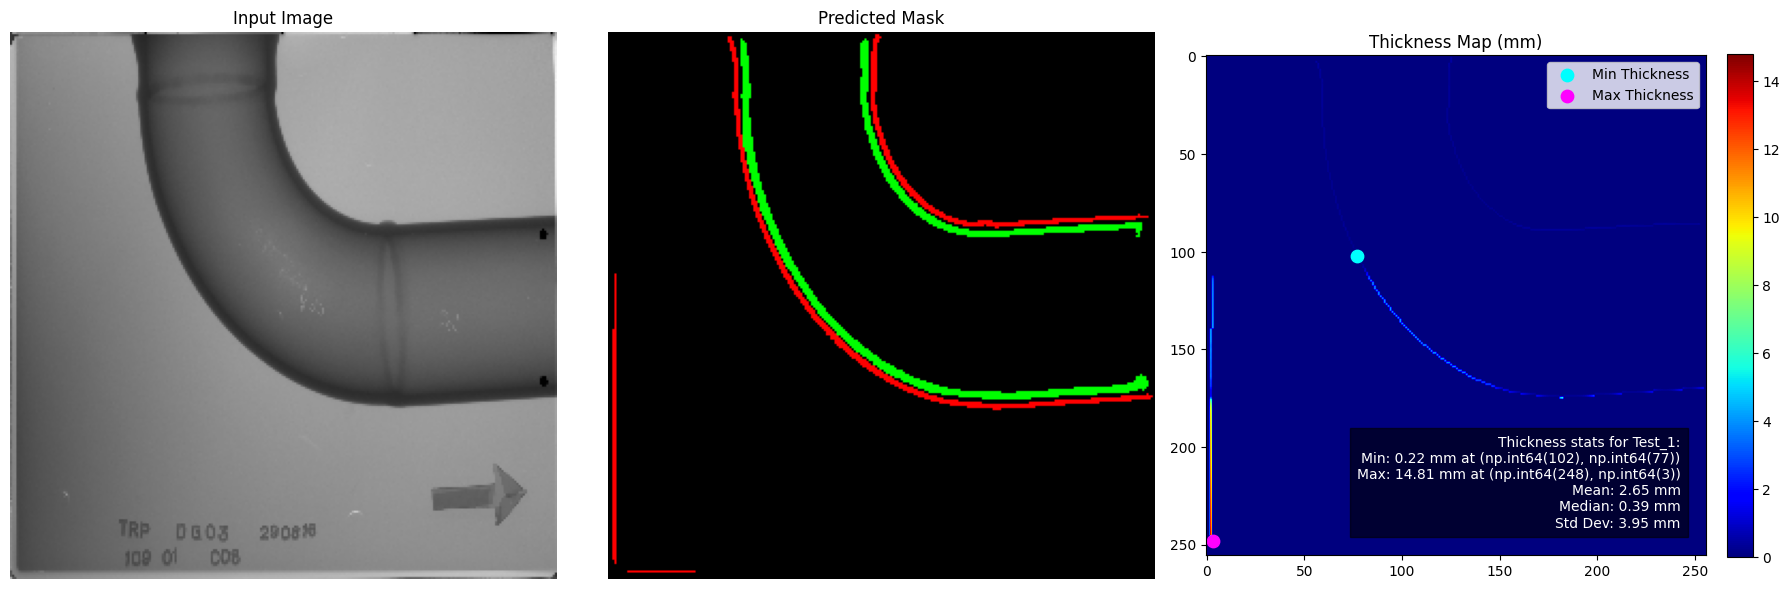

📊 Thickness stats for Test_2:
  ✅ Min     = 0.18 mm at (np.int64(152), np.int64(174))
  ✅ Max     = 0.42 mm at (np.int64(136), np.int64(22))
  ✅ Mean    = 0.29 mm
  ✅ Median  = 0.29 mm
  ✅ Std Dev = 0.06 mm


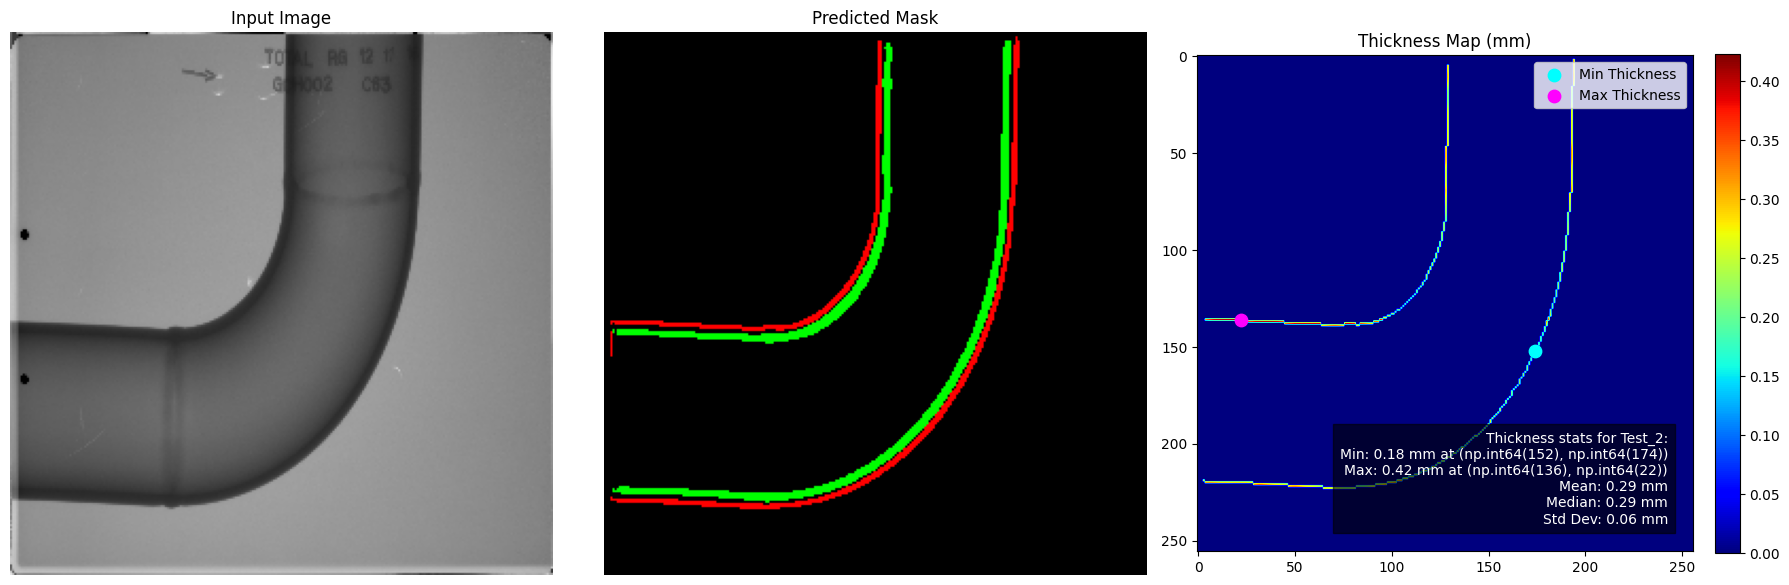

📊 Thickness stats for Test_3:
  ✅ Min     = 0.23 mm at (np.int64(165), np.int64(134))
  ✅ Max     = 4.54 mm at (np.int64(211), np.int64(2))
  ✅ Mean    = 0.58 mm
  ✅ Median  = 0.37 mm
  ✅ Std Dev = 0.80 mm


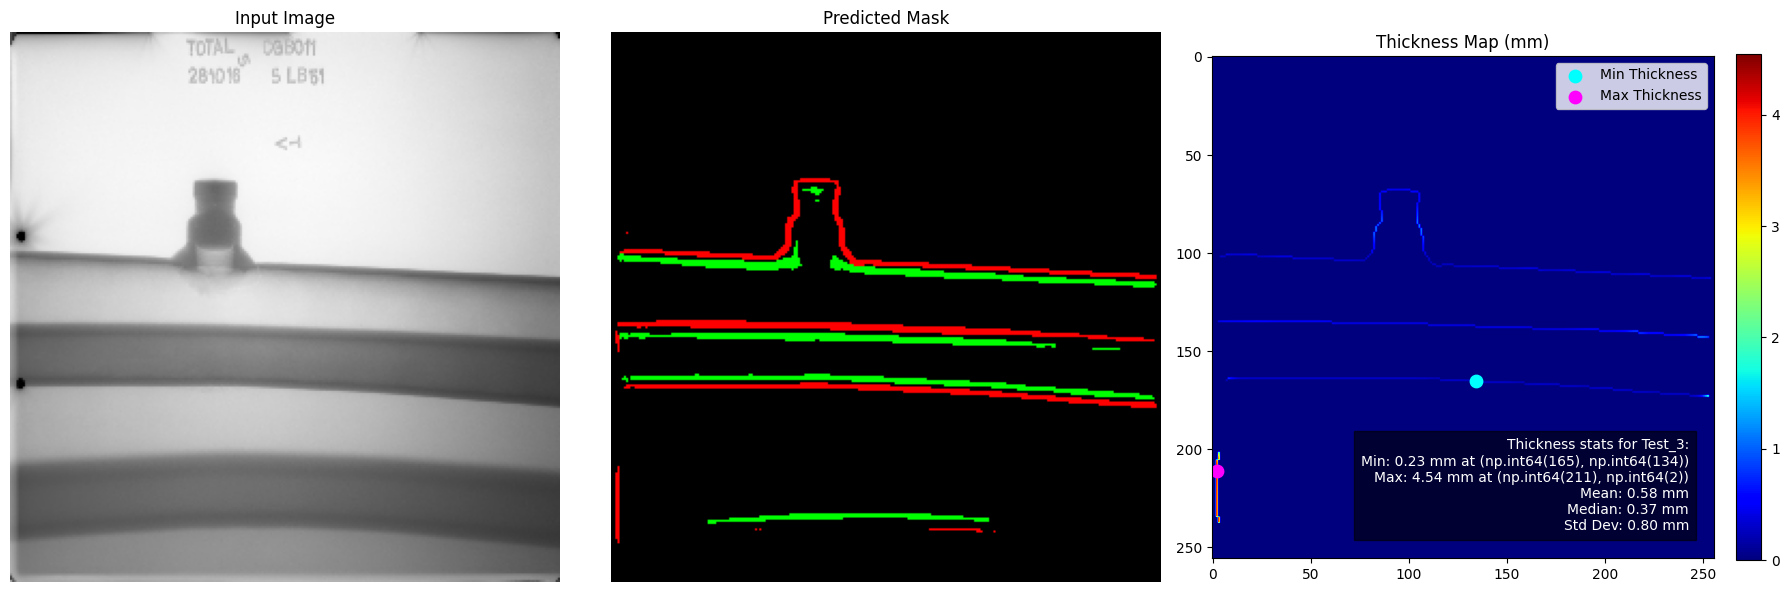

📊 Thickness stats for Test_4:
  ✅ Min     = 0.26 mm at (np.int64(240), np.int64(105))
  ✅ Max     = 4.39 mm at (np.int64(218), np.int64(245))
  ✅ Mean    = 0.79 mm
  ✅ Median  = 0.42 mm
  ✅ Std Dev = 0.96 mm


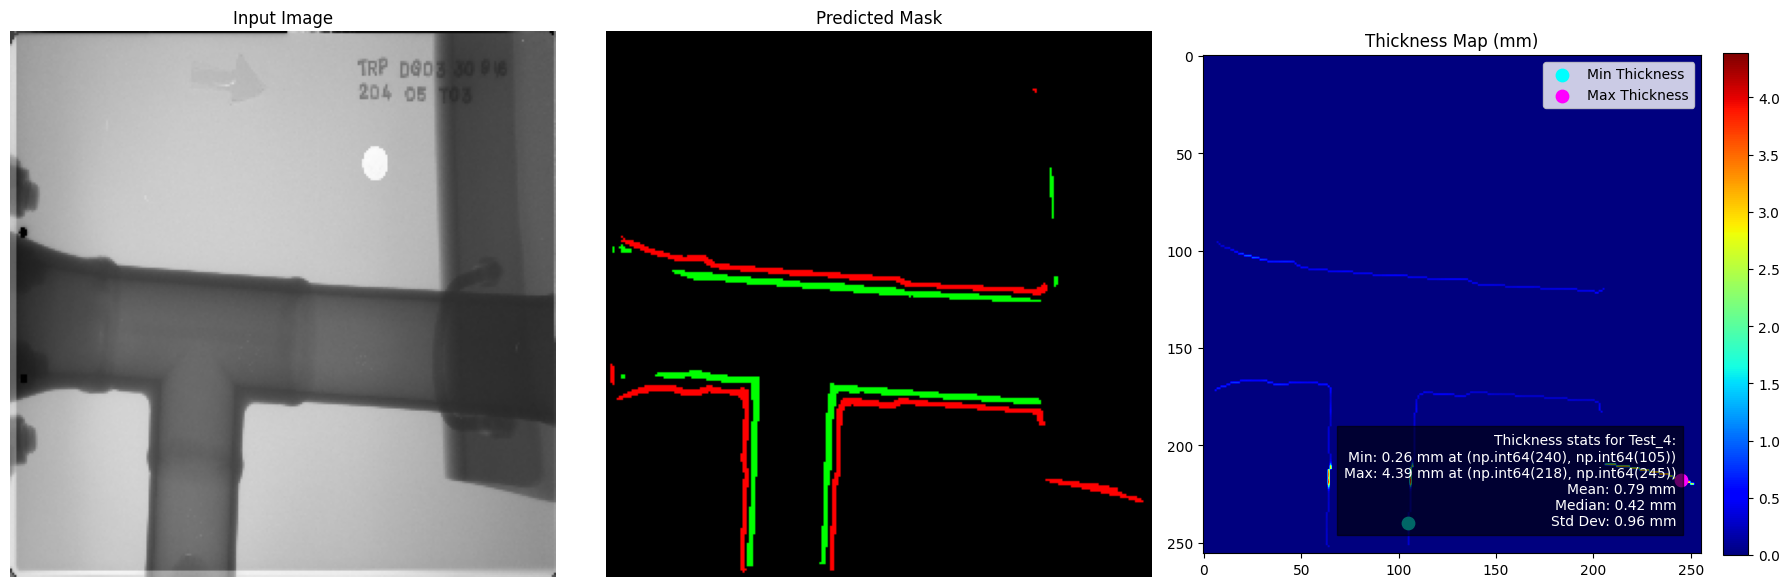

In [102]:
from scipy.ndimage import distance_transform_edt, gaussian_filter1d
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt
import numpy as np
import cv2

def colorize_mask(mask):
    h, w = mask.shape
    colored = np.zeros((h, w, 3), dtype=np.uint8)
    colored[mask == 1] = [255, 0, 0]   # Red for outer edge
    colored[mask == 2] = [0, 255, 0]   # Green for inner edge
    return colored

def visualize_prediction_with_thickness(image, pred_mask, image_name=None, visualize=True, pixel_spacing=1.0):
    try:
        stats = measure_thickness_medial_axis(
            pred_mask, visualize=False, image_name=image_name, pixel_spacing=pixel_spacing
        )
    except Exception as e:
        print(f"Skipping thickness measurement for {image_name} due to error: {e}")
        stats = None

    color_pred_mask = colorize_mask(pred_mask)

    plt.figure(figsize=(18, 6))

    # Input image
    plt.subplot(1, 3, 1)
    plt.title('Input Image')
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # Predicted mask
    plt.subplot(1, 3, 2)
    plt.title('Predicted Mask')
    plt.imshow(color_pred_mask)
    plt.axis('off')

    # Thickness map
    plt.subplot(1, 3, 3)
    if stats is not None and 'thickness_values_mm' in stats:
        thickness_map = np.zeros_like(pred_mask, dtype=np.float32)
        yy, xx = stats['medial_points']
        thickness_map[yy, xx] = stats['thickness_values_mm']

        im = plt.imshow(thickness_map, cmap='jet')
        plt.title('Thickness Map (mm)')
        plt.colorbar(im, fraction=0.046, pad=0.04)

        tv = np.array(stats['thickness_values_mm'])
        if tv.size > 0:
            min_idx = np.argmin(tv)
            max_idx = np.argmax(tv)
            min_coord = (yy[min_idx], xx[min_idx])
            max_coord = (yy[max_idx], xx[max_idx])

            # Print stats
            print(f"📊 Thickness stats for {image_name}:")
            print(f"  ✅ Min     = {np.min(tv):.2f} mm at {min_coord}")
            print(f"  ✅ Max     = {np.max(tv):.2f} mm at {max_coord}")
            print(f"  ✅ Mean    = {np.mean(tv):.2f} mm")
            print(f"  ✅ Median  = {np.median(tv):.2f} mm")
            print(f"  ✅ Std Dev = {np.std(tv):.2f} mm")

            # Mark min and max points on thickness map
            plt.scatter([min_coord[1]], [min_coord[0]], c='cyan', s=80, marker='o', label='Min Thickness')
            plt.scatter([max_coord[1]], [max_coord[0]], c='magenta', s=80, marker='o', label='Max Thickness')
            plt.legend(loc='upper right')

            # Text overlay on the plot with coordinates included
            stats_text = (
                f"Thickness stats for {image_name}:\n"
                f"Min: {np.min(tv):.2f} mm at {min_coord}\n"
                f"Max: {np.max(tv):.2f} mm at {max_coord}\n"
                f"Mean: {np.mean(tv):.2f} mm\n"
                f"Median: {np.median(tv):.2f} mm\n"
                f"Std Dev: {np.std(tv):.2f} mm"
            )
            plt.gca().text(
                0.95, 0.05, stats_text,
                fontsize=10, color='white', backgroundcolor='black',
                ha='right', va='bottom', transform=plt.gca().transAxes,
                bbox=dict(facecolor='black', alpha=0.6, pad=5)
            )
    else:
        plt.text(0.5, 0.5, 'Thickness data unavailable',
                 horizontalalignment='center', verticalalignment='center',
                 fontsize=14)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# Example usage
preds = model.predict(X_test)
pred_labels = np.argmax(preds, axis=-1)

for i in range(min(5, len(X_test))):
    visualize_prediction_with_thickness(
        X_test[i], pred_labels[i], image_name=f"Test_{i}", pixel_spacing=0.1
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
📊 Thickness stats for Test_0:
  ✅ Min     = 0.20 mm at (np.int64(91), np.int64(21))
  ✅ Max     = 0.24 mm at (np.int64(155), np.int64(87))
  ✅ Mean    = 0.21 mm
  ✅ Median  = 0.21 mm
  ✅ Std Dev = 0.01 mm


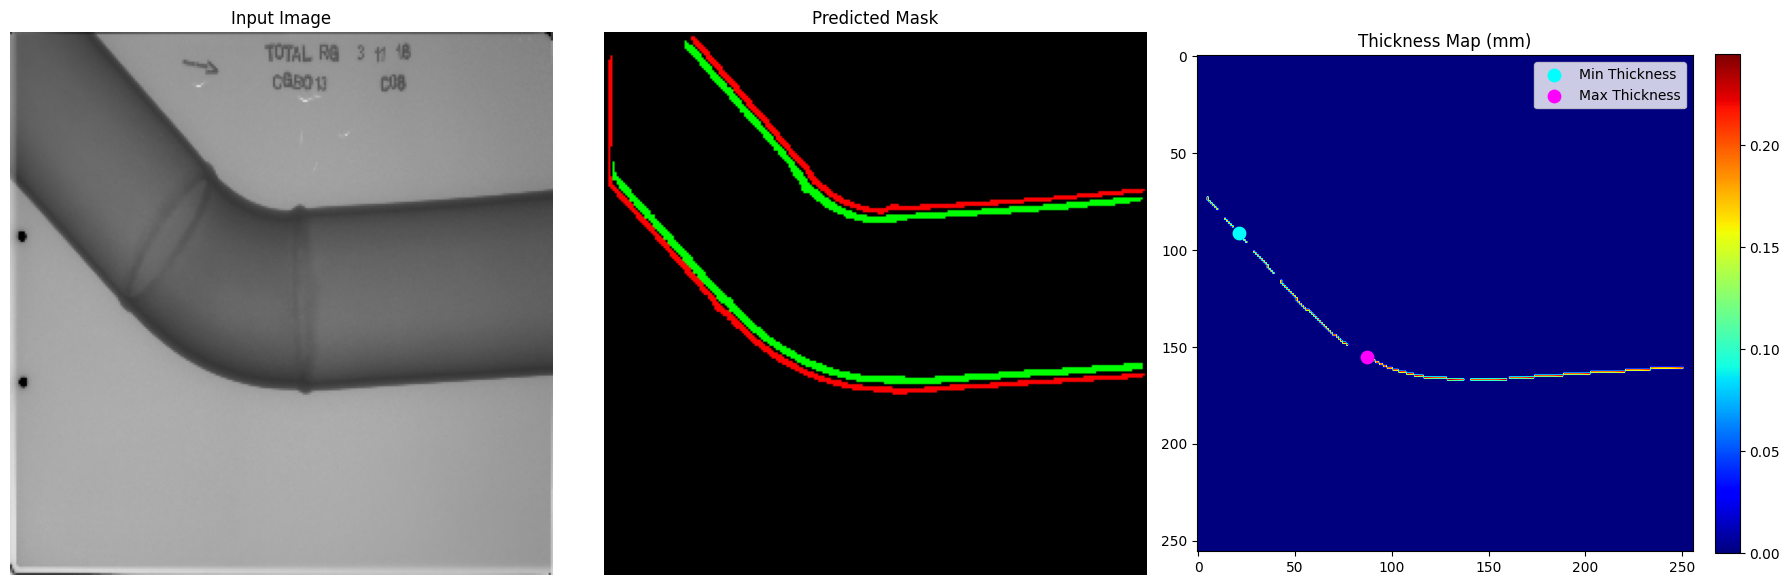

📊 Thickness stats for Test_1:
  ✅ Min     = 0.20 mm at (np.int64(171), np.int64(218))
  ✅ Max     = 0.26 mm at (np.int64(27), np.int64(60))
  ✅ Mean    = 0.22 mm
  ✅ Median  = 0.21 mm
  ✅ Std Dev = 0.02 mm


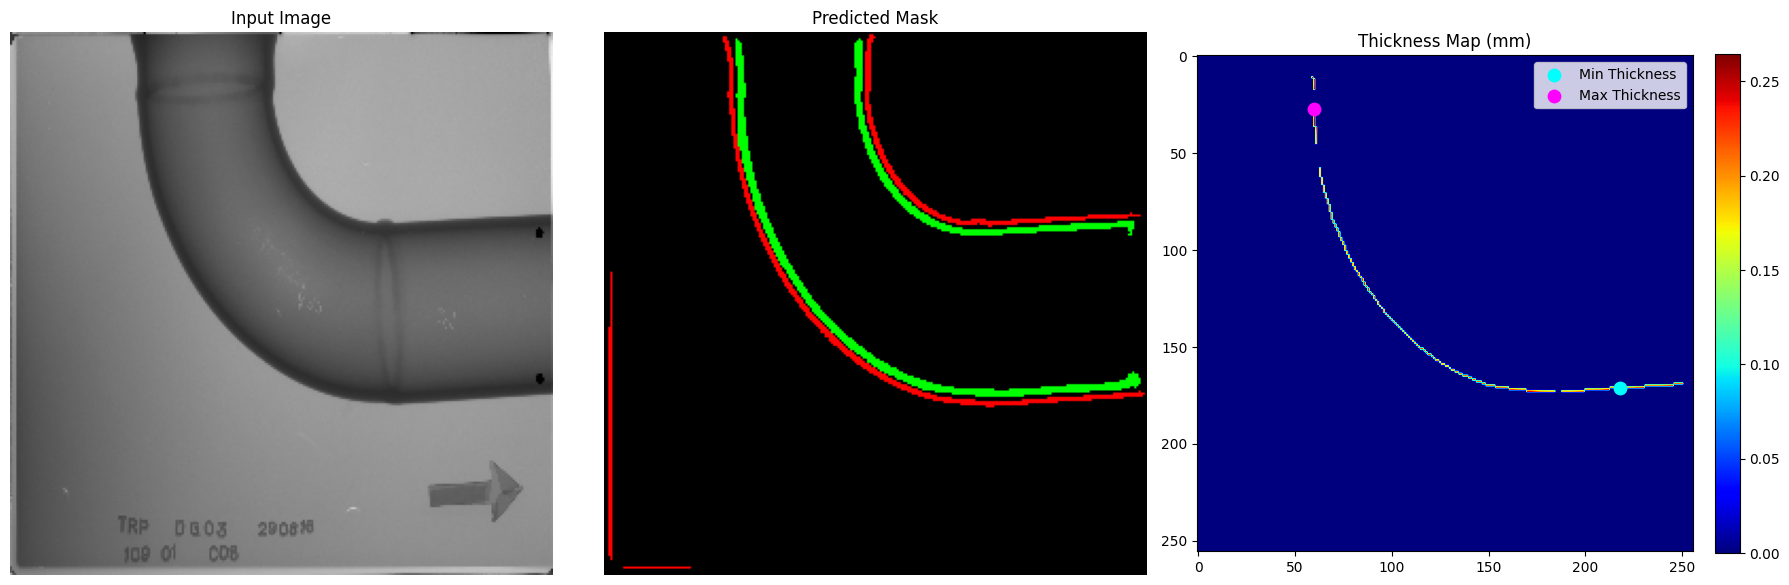

📊 Thickness stats for Test_2:
  ✅ Min     = 0.18 mm at (np.int64(137), np.int64(180))
  ✅ Max     = 0.24 mm at (np.int64(223), np.int64(78))
  ✅ Mean    = 0.21 mm
  ✅ Median  = 0.20 mm
  ✅ Std Dev = 0.01 mm


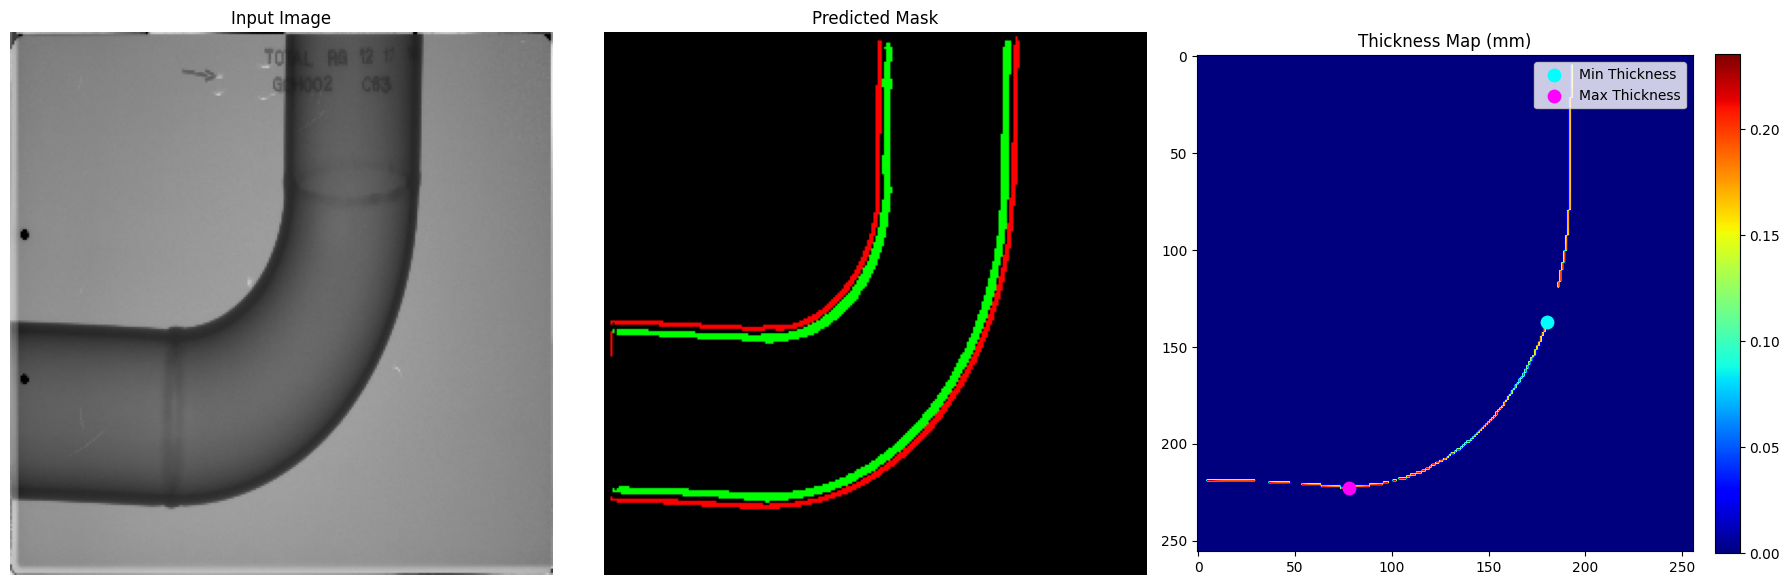

📊 Thickness stats for Test_3:
  ✅ Min     = 2.20 mm at (np.int64(139), np.int64(143))
  ✅ Max     = 2.50 mm at (np.int64(143), np.int64(228))
  ✅ Mean    = 2.31 mm
  ✅ Median  = 2.30 mm
  ✅ Std Dev = 0.08 mm


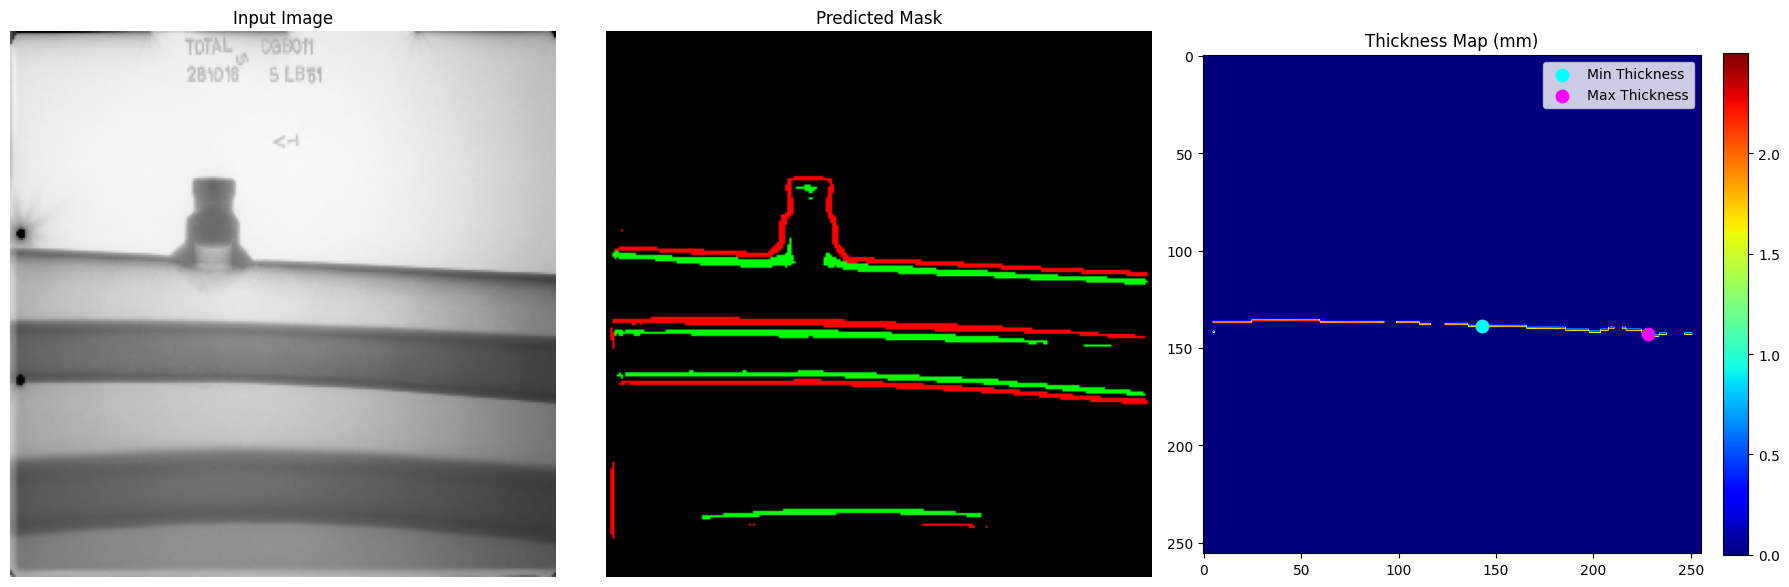

📊 Thickness stats for Test_4:
  ✅ Min     = 4.96 mm at (np.int64(120), np.int64(158))
  ✅ Max     = 10.87 mm at (np.int64(101), np.int64(17))
  ✅ Mean    = 6.21 mm
  ✅ Median  = 5.05 mm
  ✅ Std Dev = 1.73 mm


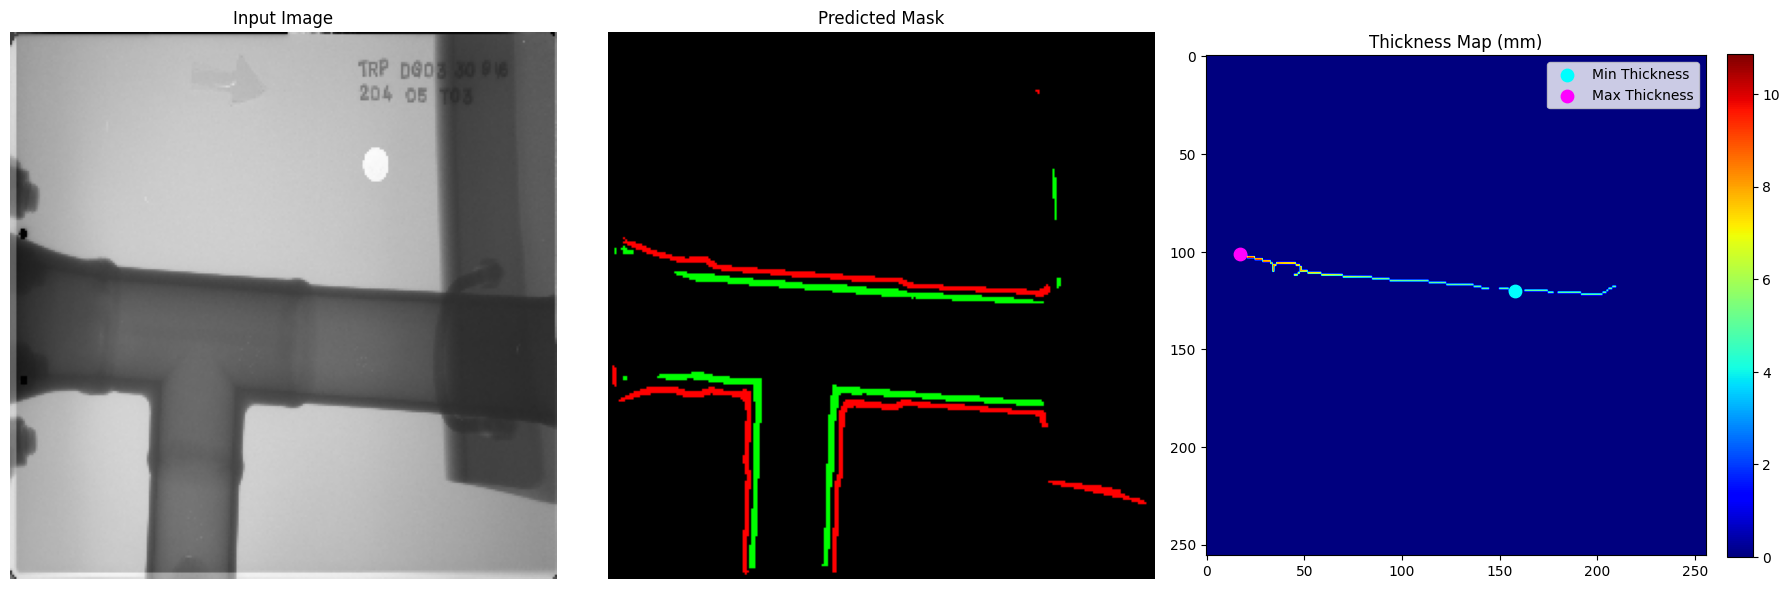

In [113]:
from scipy.ndimage import distance_transform_edt, gaussian_filter1d
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# ---------------------
# 1️⃣ Clean mask
# ---------------------
def clean_pipe_mask(mask, min_component_area=200, bridge_kernel=5):
    mask = mask.copy().astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (bridge_kernel, bridge_kernel))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    cleaned = np.zeros_like(mask)
    for cls in [1, 2]:  # Outer = 1, Inner = 2
        binary = (mask == cls).astype(np.uint8)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)
        if num_labels > 1:
            largest_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            binary = (labels == largest_idx).astype(np.uint8)
        cleaned[binary == 1] = cls

    return cleaned

# ---------------------
# 2️⃣ Measure thickness
# ---------------------
def measure_pipe_wall_thickness(mask, original_shape=None, resized_shape=None,
                                visualize=False, image_name=None,
                                min_wall_area=50, pixel_spacing=1.0,
                                border_margin=5):  # NEW: margin to ignore edges
    if resized_shape is None:
        resized_shape = mask.shape[:2]

    mask = clean_pipe_mask(mask, min_component_area=min_wall_area)

    outer_edge = (mask == 1).astype(np.uint8)
    inner_edge = (mask == 2).astype(np.uint8)
    if np.sum(outer_edge) == 0 or np.sum(inner_edge) == 0:
        raise ValueError("Missing outer or inner edge in mask")

    # Safe contour filling
    def fill_contour(edge_mask):
        filled = np.zeros_like(edge_mask, dtype=np.uint8)
        contours, _ = cv2.findContours(edge_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) > 0:
            cv2.drawContours(filled, contours, -1, 1, thickness=-1)
        return filled

    outer_filled = fill_contour(outer_edge)
    inner_filled = fill_contour(inner_edge)
    pipe_wall_mask = cv2.bitwise_and(outer_filled, cv2.bitwise_not(inner_filled))

    # Remove small components
    num_labels, labels, stats_cc, _ = cv2.connectedComponentsWithStats(pipe_wall_mask, connectivity=8)
    for i in range(1, num_labels):
        if stats_cc[i, cv2.CC_STAT_AREA] < min_wall_area:
            pipe_wall_mask[labels == i] = 0

    if np.sum(pipe_wall_mask) == 0:
        raise ValueError("No valid pipe wall found after filtering")

    # Medial axis & distance transforms
    medial_axis = skeletonize(pipe_wall_mask).astype(np.uint8)
    if np.sum(medial_axis) == 0:
        raise ValueError("No medial axis found")
    dist_to_outer = distance_transform_edt(1 - outer_edge)
    dist_to_inner = distance_transform_edt(1 - inner_edge)

    medial_points = np.where(medial_axis == 1)
    thickness_values = dist_to_outer[medial_points] + dist_to_inner[medial_points]

    # FILTER POINTS NEAR IMAGE EDGES
    h, w = mask.shape[:2]
    yy, xx = medial_points
    valid_mask = (yy >= border_margin) & (yy < h - border_margin) & \
                 (xx >= border_margin) & (xx < w - border_margin)
    medial_points = (yy[valid_mask], xx[valid_mask])
    thickness_values = thickness_values[valid_mask]

    if len(thickness_values) > 3:
        thickness_values = gaussian_filter1d(thickness_values, sigma=3)

    # Scale to original image and mm
    if original_shape is not None:
        orig_h, orig_w = original_shape
        resized_h, resized_w = resized_shape
        scale = (orig_h / resized_h + orig_w / resized_w) / 2
    else:
        scale = 1.0
    thickness_values_mm = thickness_values * scale * pixel_spacing

    # Filter outliers 5-95 percentile
    if thickness_values_mm.size > 0:
        q_low, q_high = np.percentile(thickness_values_mm, [5, 95])
        valid_idx = (thickness_values_mm >= q_low) & (thickness_values_mm <= q_high)
        tv_mm_filtered = thickness_values_mm[valid_idx]
        medial_points_filtered = (medial_points[0][valid_idx], medial_points[1][valid_idx])
    else:
        tv_mm_filtered = thickness_values_mm
        medial_points_filtered = medial_points

    stats = {
        'thickness_values_mm': tv_mm_filtered,
        'medial_points': medial_points_filtered,
        'scale_factor': scale
    }

    # Visualization
    if visualize:
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))

        axs[0].imshow(mask, cmap='gray')
        axs[0].set_title("Cleaned Mask")
        axs[0].axis('off')

        axs[1].imshow(pipe_wall_mask, cmap='gray')
        axs[1].scatter(medial_points_filtered[1], medial_points_filtered[0], s=1, c='red')
        axs[1].set_title("Pipe Wall + Medial Axis")
        axs[1].axis('off')

        thickness_img_mm = np.zeros_like(mask, dtype=np.float32)
        thickness_img_mm[medial_points_filtered] = tv_mm_filtered
        im = axs[2].imshow(thickness_img_mm, cmap='jet')
        axs[2].set_title("Thickness Map (mm)")
        axs[2].axis('off')
        plt.colorbar(im, ax=axs[2], label='Thickness (mm)')

        axs[3].hist(tv_mm_filtered, bins=30, color='gray')
        axs[3].set_title("Filtered Thickness Histogram (mm)")
        axs[3].set_xlabel("Thickness (mm)")
        axs[3].grid(True)

        plt.suptitle(f"Thickness Analysis - {image_name}\nScale: {scale:.3f}, Pixel Spacing: {pixel_spacing} mm/px", fontsize=16)
        plt.tight_layout()
        plt.show()

    return stats

# ---------------------
# 3️⃣ Color mask
# ---------------------
def colorize_mask(mask):
    h, w = mask.shape
    colored = np.zeros((h, w, 3), dtype=np.uint8)
    colored[mask == 1] = [255, 0, 0]   # Red for outer edge
    colored[mask == 2] = [0, 255, 0]   # Green for inner edge
    return colored

# ---------------------
# 4️⃣ Visualize prediction with thickness
# ---------------------
def visualize_prediction_with_thickness(image, pred_mask, image_name=None, pixel_spacing=1.0):
    stats = None
    try:
        stats = measure_pipe_wall_thickness(
            pred_mask, visualize=False, image_name=image_name, pixel_spacing=pixel_spacing
        )
    except Exception as e:
        print(f"⚠ Skipping thickness measurement for {image_name}: {e}")

    color_pred_mask = colorize_mask(pred_mask)

    plt.figure(figsize=(18, 6))

    # Input image
    plt.subplot(1, 3, 1)
    plt.title('Input Image')
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # Predicted mask
    plt.subplot(1, 3, 2)
    plt.title('Predicted Mask')
    plt.imshow(color_pred_mask)
    plt.axis('off')

    # Thickness map
    plt.subplot(1, 3, 3)
    if stats is not None and stats['thickness_values_mm'].size > 0:
        thickness_map = np.zeros_like(pred_mask, dtype=np.float32)
        yy, xx = stats['medial_points']
        tv = stats['thickness_values_mm']

        min_len = min(len(yy), len(tv))
        thickness_map[yy[:min_len], xx[:min_len]] = tv[:min_len]

        im = plt.imshow(thickness_map, cmap='jet')
        plt.title('Thickness Map (mm)')
        plt.colorbar(im, fraction=0.046, pad=0.04)

        min_idx, max_idx = np.argmin(tv[:min_len]), np.argmax(tv[:min_len])
        min_coord, max_coord = (yy[min_idx], xx[min_idx]), (yy[max_idx], xx[max_idx])

        # Print stats
        print(f"📊 Thickness stats for {image_name}:")
        print(f"  ✅ Min     = {np.min(tv[:min_len]):.2f} mm at {min_coord}")
        print(f"  ✅ Max     = {np.max(tv[:min_len]):.2f} mm at {max_coord}")
        print(f"  ✅ Mean    = {np.mean(tv[:min_len]):.2f} mm")
        print(f"  ✅ Median  = {np.median(tv[:min_len]):.2f} mm")
        print(f"  ✅ Std Dev = {np.std(tv[:min_len]):.2f} mm")

        # Mark min/max points
        plt.scatter([min_coord[1]], [min_coord[0]], c='cyan', s=80, marker='o', label='Min Thickness')
        plt.scatter([max_coord[1]], [max_coord[0]], c='magenta', s=80, marker='o', label='Max Thickness')
        plt.legend(loc='upper right')

    else:
        plt.text(0.5, 0.5, 'Thickness data unavailable',
                 horizontalalignment='center', verticalalignment='center',
                 fontsize=14)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# ---------------------
# 5️⃣ Example usage
# ---------------------
preds = model.predict(X_test)
pred_labels = np.argmax(preds, axis=-1)

for i in range(min(5, len(X_test))):
    visualize_prediction_with_thickness(
        X_test[i], pred_labels[i], image_name=f"Test_{i}", pixel_spacing=0.1
    )
